# Data Cleaning

## Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import zipfile


raw_data_path = "../data/raw_data/"
clean_data_path = "../data/cleaned_data/"

def save_clean_data(df, file_name):
    os.makedirs(clean_data_path, exist_ok=True)
    df.to_csv(clean_data_path + file_name, index=False)

def unzip_raw_data(zip_path="../data/data.zip", extract_to="../data/"):
    # Ensure output directory exists
    os.makedirs(extract_to, exist_ok=True)

    # Unzip
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    print(f"Uncompressed {zip_path} → {extract_to}")

unzip_raw_data()

Uncompressed ../data/data.zip → ../data/


### Wine data

In [2]:
wine_red_data_raw = pd.read_csv(raw_data_path + "winequality/winequality-red.csv", sep=";")
wine_white_data_raw = pd.read_csv(raw_data_path + "winequality/winequality-white.csv", sep=";")

### Retail data

In [3]:
online_retail_data_raw = pd.read_excel(raw_data_path + "retail/Online Retail.xlsx")

### Cup98

In [4]:
cup98_data_raw = pd.read_csv(raw_data_path + "cup98/cup98LRN.txt")

/tmp/ipykernel_6895/381543648.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  cup98_data_raw = pd.read_csv(raw_data_path + "cup98/cup98LRN.txt")


In [5]:
def visualize_missing(df_v, name, sample_n=1000):
    ncols = df_v.shape[1]
    miss_pct = df_v.isna().mean().sort_values(ascending=False) * 100

    # MUCH larger figure and more spacing
    fig = plt.figure(constrained_layout=True, figsize=(18, 12))
    gs = fig.add_gridspec(
        2, 3,
        height_ratios=[1.2, 1.5],   # make heatmap row bigger
        width_ratios=[2, 2, 1.2]     # give barplot more room
    )

    # --- BARPLOT (Top Missing Columns) ---
    ax0 = fig.add_subplot(gs[0, :2])
    sns.barplot(
        x=miss_pct.values[:40],
        y=miss_pct.index[:40],
        palette="viridis",
        ax=ax0
    )
    ax0.set_xlabel("Missing %", fontsize=12)
    ax0.set_title(f"{name} — Top Missing Columns (up to 40)", fontsize=14)
    ax0.tick_params(labelsize=10)
    ax0.grid(axis="x", linestyle="--", alpha=0.3)

    # --- INFO PANEL ---
    ax1 = fig.add_subplot(gs[0, 2])
    ax1.axis("off")
    ax1.text(
        0, 0.7,
        f"Rows: {len(df_v)}\n"
        f"Columns: {ncols}\n"
        f"Columns w/ missing: {(miss_pct>0).sum()}\n"
        f"Max missing %: {miss_pct.max():.1f}%",
        fontsize=12
    )

    # --- HEATMAP ---
    sample = df_v if len(df_v) <= sample_n else df_v.sample(sample_n, random_state=0)
    miss_mat = sample.isna().astype(int).T

    max_cols_for_heatmap = 80
    if miss_mat.shape[1] > max_cols_for_heatmap:
        miss_mat = miss_mat.iloc[:, :max_cols_for_heatmap]
        title = f"{name} — Missingness Heatmap\n(sample {len(sample)} rows, first {max_cols_for_heatmap} columns)"
    else:
        title = f"{name} — Missingness Heatmap\n(sample {len(sample)} rows)"

    ax2 = fig.add_subplot(gs[1, :])

    # Increase heatmap cell size
    sns.heatmap(
        miss_mat,
        cbar=False,
        cmap=["#2b8cbe", "#f7f7f7"],
        ax=ax2,
        linewidths=0,
    )

    ax2.set_title(title, fontsize=14)
    ax2.set_ylabel("Columns (transposed)", fontsize=12)
    ax2.set_xlabel("Sampled Rows", fontsize=12)
    ax2.tick_params(labelsize=9)

    plt.show()


/tmp/ipykernel_6895/1142672042.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


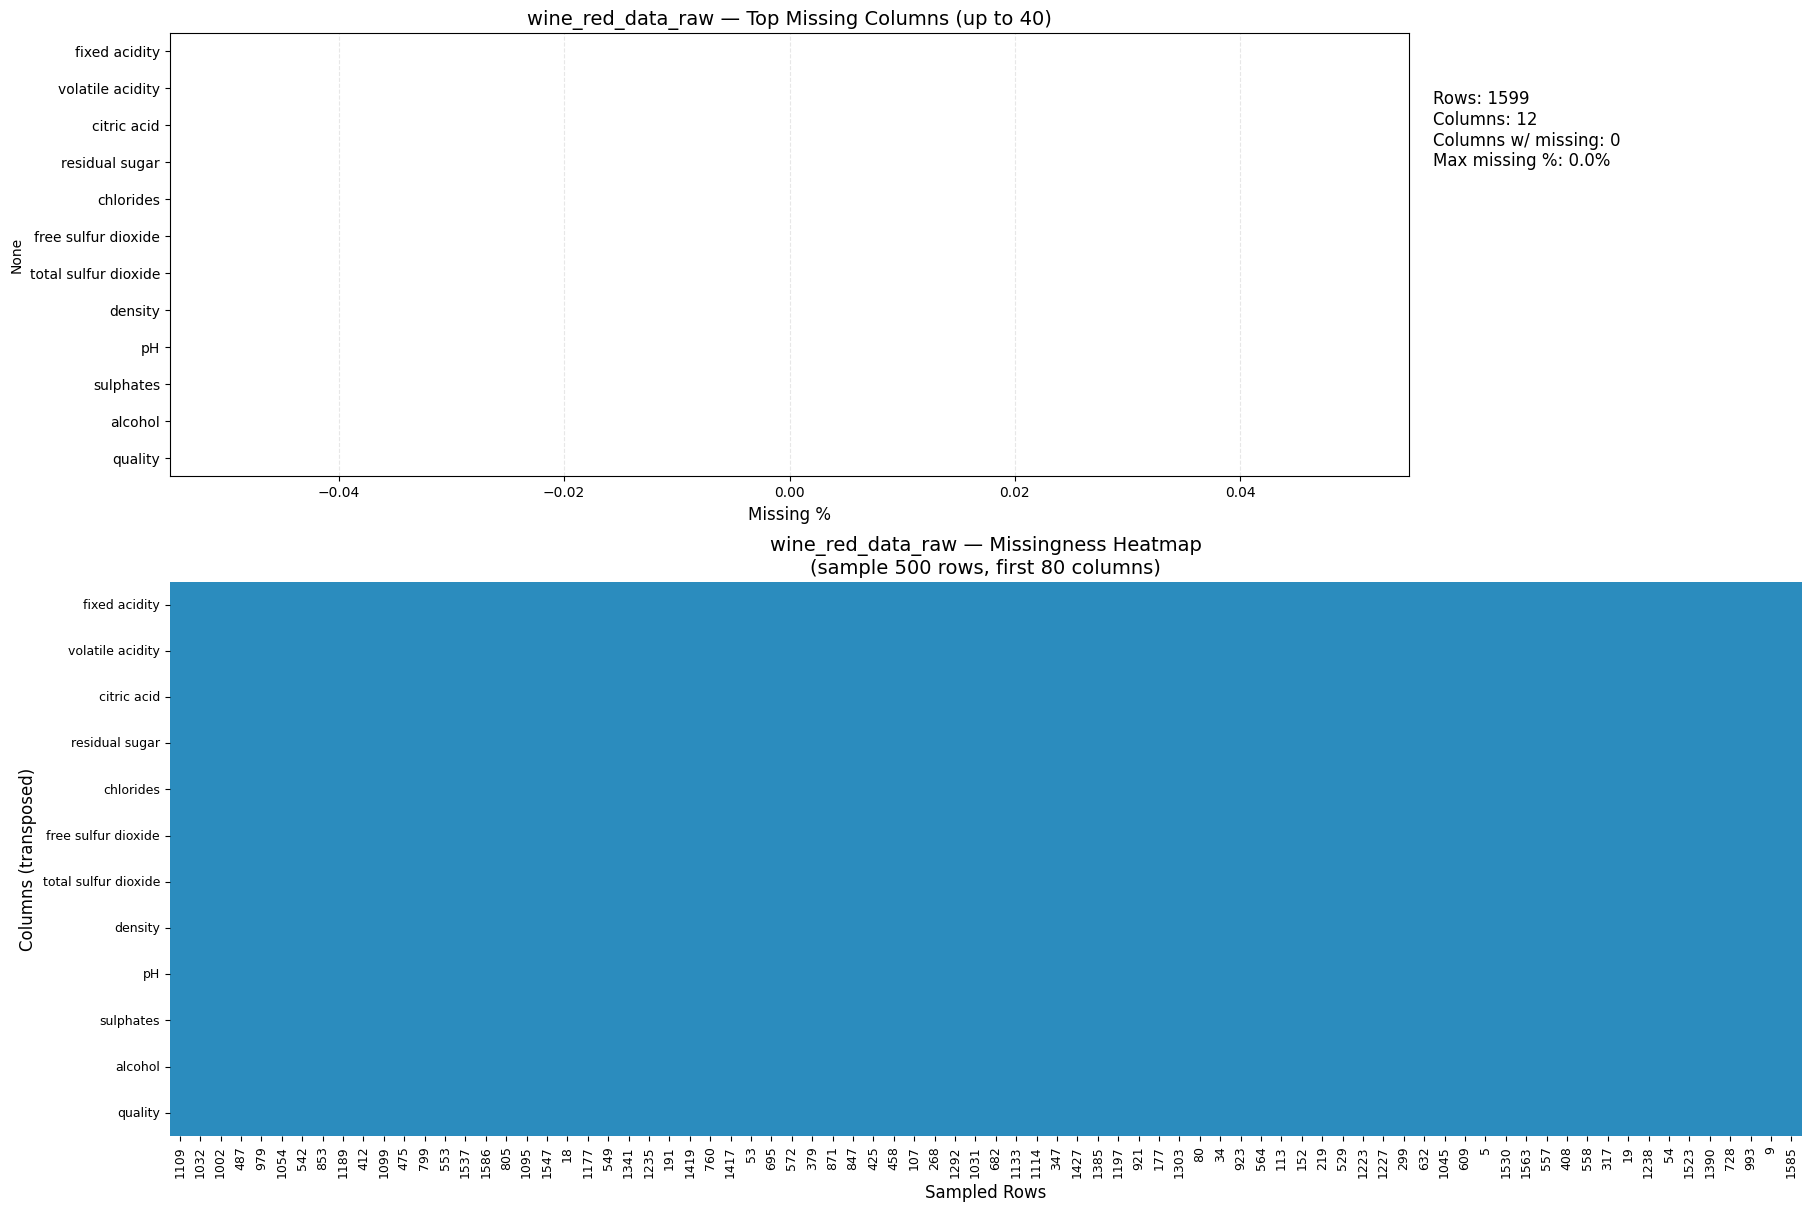

/tmp/ipykernel_6895/1142672042.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


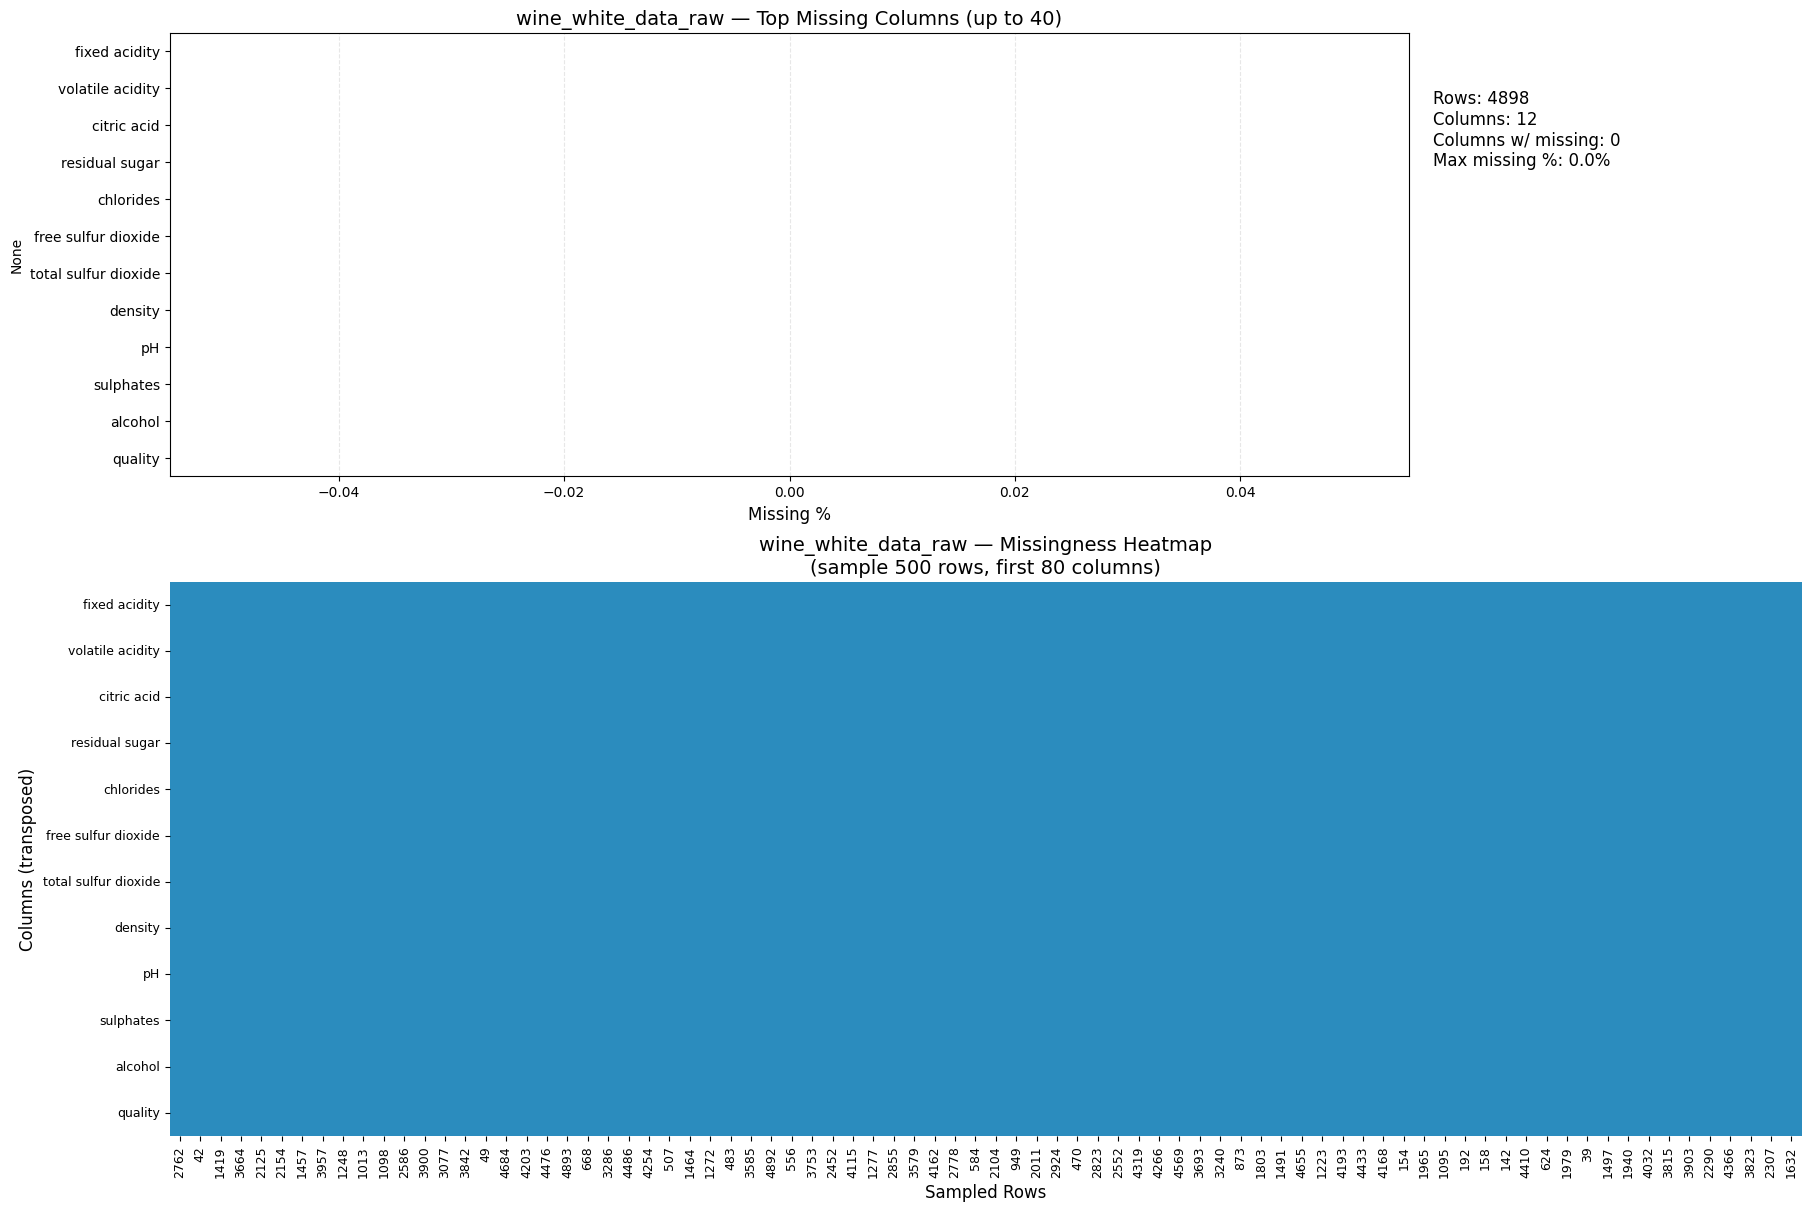

/tmp/ipykernel_6895/1142672042.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


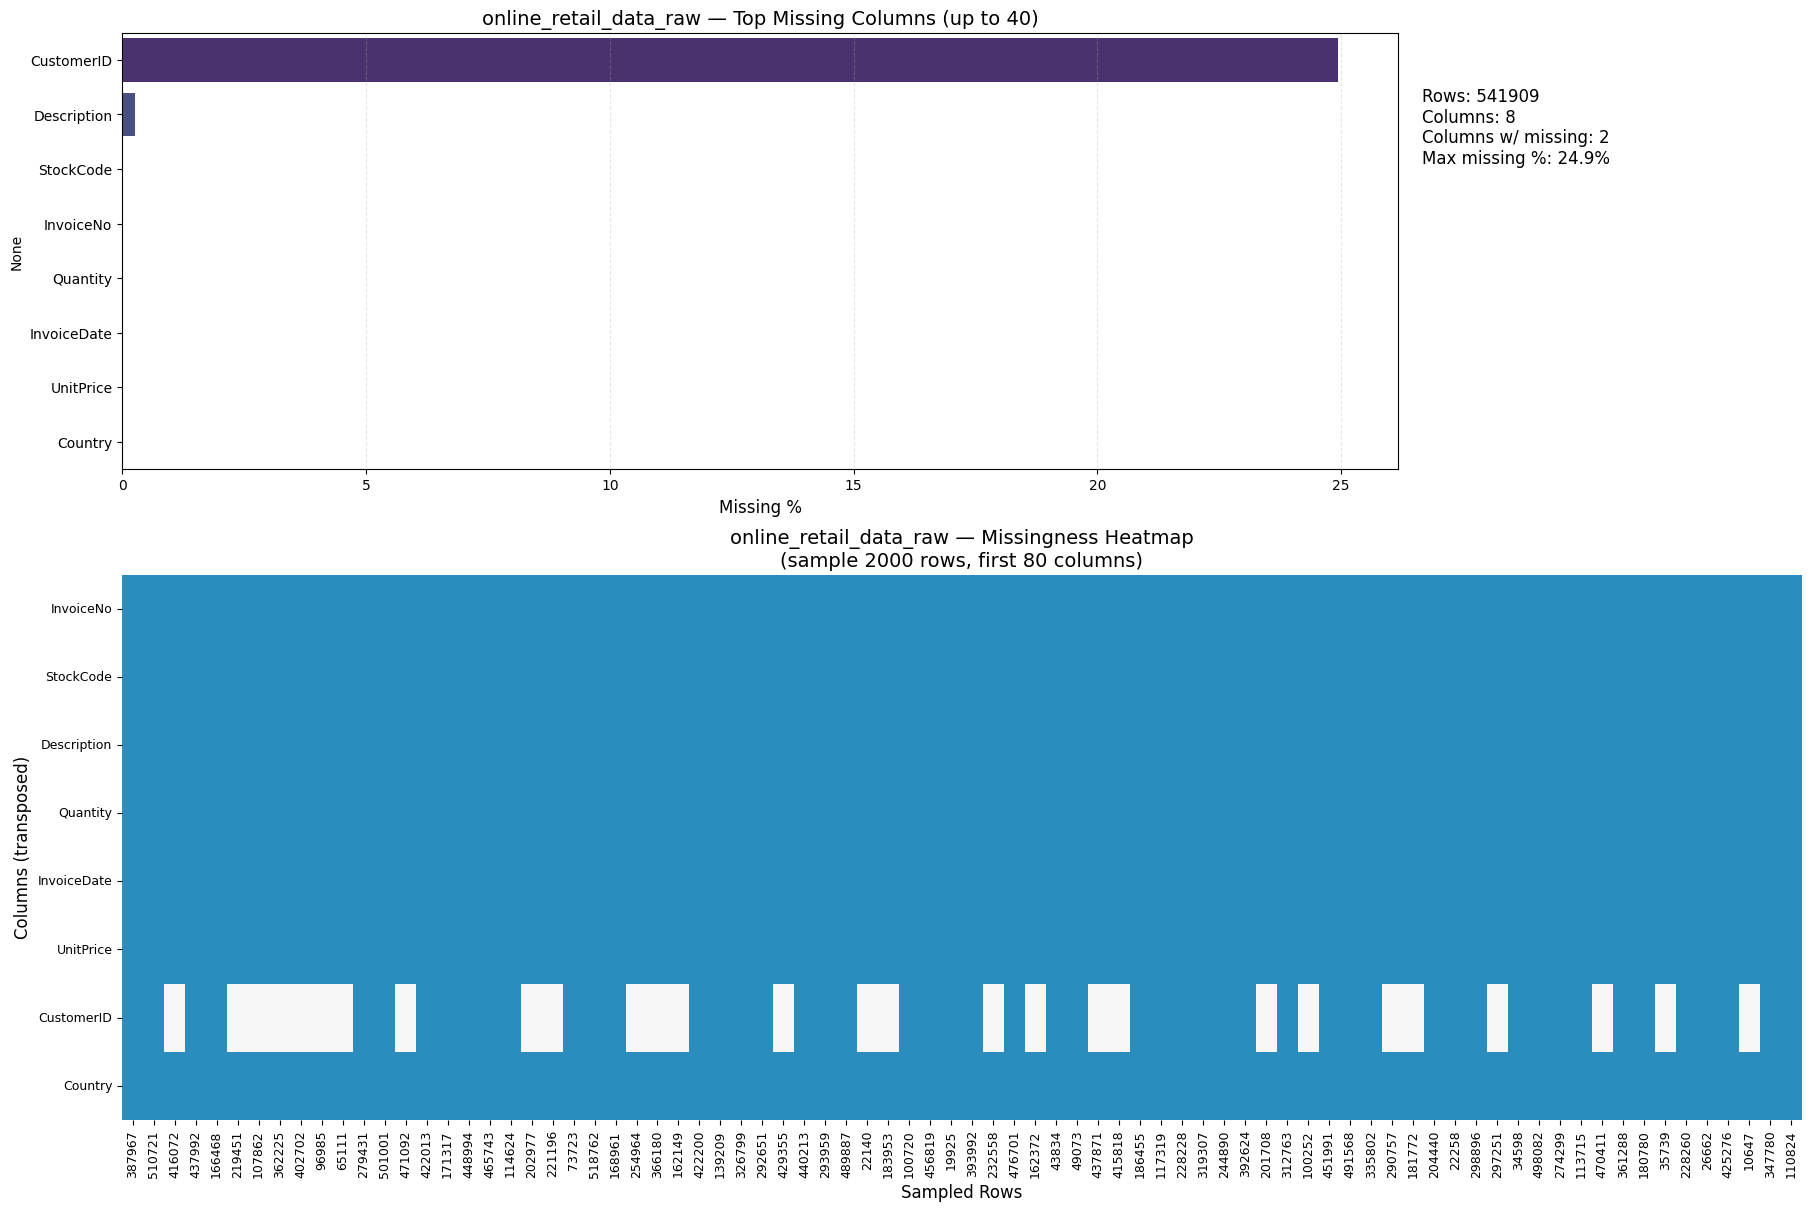

/tmp/ipykernel_6895/1142672042.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


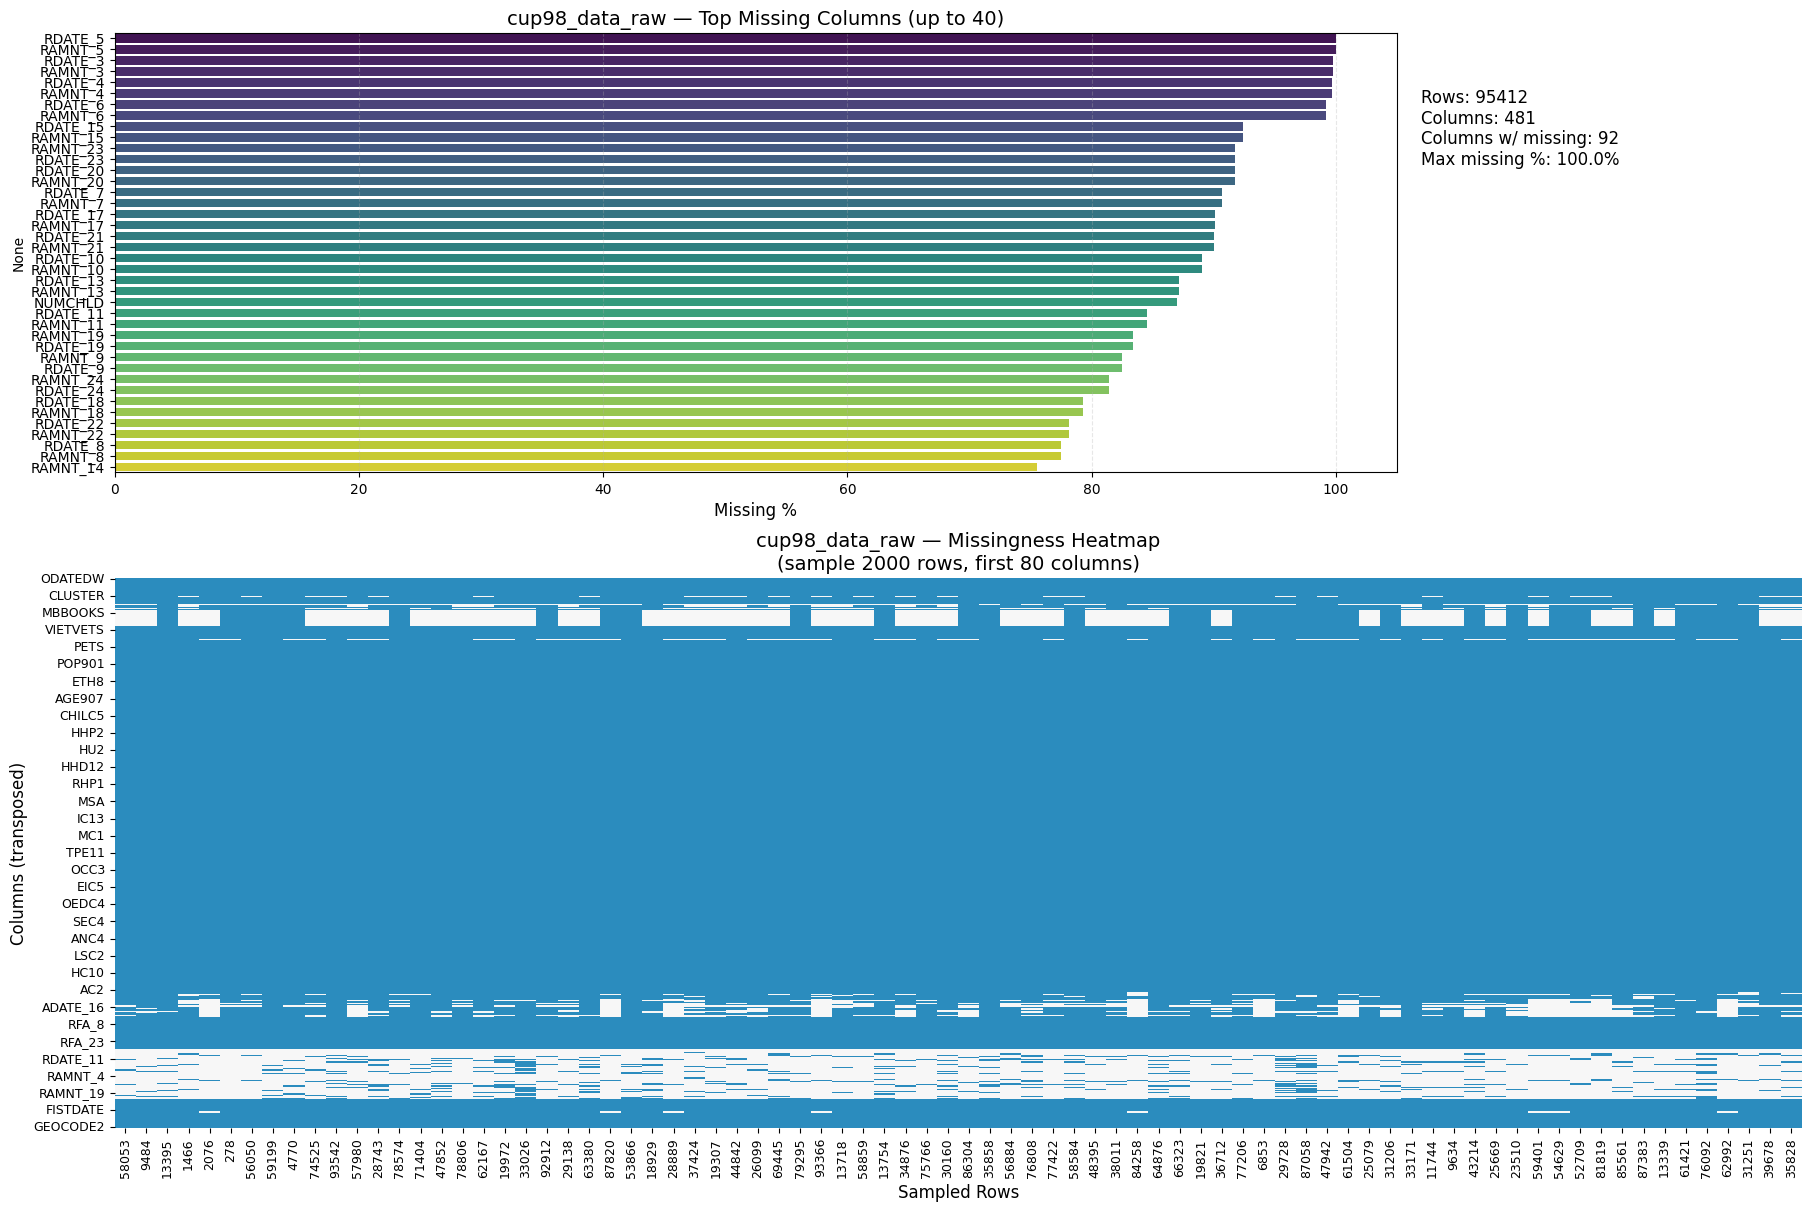

In [6]:
visualize_missing(wine_red_data_raw, "wine_red_data_raw", sample_n=500)
visualize_missing(wine_white_data_raw, "wine_white_data_raw", sample_n=500)
visualize_missing(online_retail_data_raw, "online_retail_data_raw", sample_n=2000)
visualize_missing(cup98_data_raw, "cup98_data_raw", sample_n=2000)

## Online_Retail

If we are analyzing individual customer behavior, there is no need for ones without ID. As they are probably one-time purchasers that add not significant effect to our modeling goal

In [7]:
online_retail_data_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
online_retail_data = online_retail_data_raw.copy()
online_retail_data = online_retail_data.dropna(subset=["CustomerID"])

In [9]:
save_clean_data(online_retail_data, "online_retail_data_clean.csv")

## winequality

In [10]:
wine_red_data_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [11]:
wine_white_data_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [12]:
save_clean_data(wine_red_data_raw, "wine_red_data_clean.csv")
save_clean_data(wine_white_data_raw, "wine_white_data_clean.csv")

## Cup98

In this study: https://lowrank.net/nikos/pubs/empirical.pdf
They did mean imputation for missing values, and everything thats missing was literally just "MISSING"
- Here I dropped all columns where >50% of the values are missing

“KDD98 is from the 1998 KDD-Cup. The task is to predict if a person donates money.
This is the only dataset with missing values. We impute the mean for continuous features and treat missing nominal and boolean features as new values.” (Page 3)

In [13]:
def impute_cup98(df):
    df = df.copy()

    for col in df.columns:

        # --- 1. Try converting to numeric to detect mixed-type numeric/binary flags
        coerced = pd.to_numeric(df[col], errors="coerce")

        # Case A: Column *becomes* numeric after coercion → treat as numeric (binary or continuous)
        if coerced.notna().sum() > 0 and coerced.isna().sum() < len(df):
            # Use coerced version when possible
            df[col] = coerced
            # Numeric imputation → mean
            df[col] = df[col].fillna(df[col].mean())
            continue

        # Case B: Column does NOT coerce to numeric → treat as categorical
        else:
            # Replace missing-like tokens with "MISSING"
            df[col] = df[col].astype(str).replace(["", " ", "X", "nan", "NaN"], "MISSING")
            df[col] = df[col].fillna("MISSING")
            continue

    return df

In [14]:
cup98_data_raw = cup98_data_raw.loc[:, cup98_data_raw.isna().mean() < 0.50]
cup98_data_clean = impute_cup98(cup98_data_raw)


save_clean_data(cup98_data_clean, "cup98_data_clean.csv")